# Notebook 3 — Feature Selection

Objectif : identifier les variables les plus **pertinentes et non redondantes** pour prédire `sleep_duration_hours` et `stress_level`.

**Outils :** Scikit-learn (SelectKBest, RandomForest importance, RFE) · Pandas

**Source :** `dataset_engineered.csv` (issu du notebook 2)

---
### Pourquoi faire de la feature selection ?
Trop de variables = modèle sur-ajusté, lent, et difficile à interpréter. La sélection permet de garder **uniquement ce qui apporte de l'information**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)

df = pd.read_csv('dataset_engineered.csv')
print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Dataset chargé : 15,000 lignes × 45 colonnes


## 1. Préparation : matrice X et vecteurs cibles y

In [2]:
# Colonnes à exclure de X (identifiants, cibles, colonnes binned/textuelles)
exclude_cols = [
    'user_id', 'gender', 'occupation',
    'sleep_duration_hours', 'stress_level',  # cibles
    'screen_time_bin', 'age_group',           # catégorielles texte
]

feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in [np.float64, np.int64, float, int]]
# Supprimer les colonnes avec des NaN
df_model = df[feature_cols + ['sleep_duration_hours', 'stress_level']].dropna()

X = df_model[feature_cols]
y_sleep  = df_model['sleep_duration_hours']
y_stress = df_model['stress_level']

print(f'Nombre de features candidates : {len(feature_cols)}')
print(f'Taille du dataset             : {X.shape[0]:,} observations')
print(f'\nFeatures :')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:>2}. {col}')

Nombre de features candidates : 31
Taille du dataset             : 14,415 observations

Features :
   1. age
   2. daily_screen_time_hours
   3. phone_usage_before_sleep_minutes
   4. sleep_quality_score
   5. caffeine_intake_cups
   6. physical_activity_minutes
   7. notifications_received_per_day
   8. mental_fatigue_score
   9. screen_to_sleep_ratio
  10. pre_sleep_phone_pct
  11. notif_per_screen_hour
  12. digital_load_hours
  13. stress_fatigue_index
  14. wellness_score
  15. sleep_deficit_hours
  16. is_heavy_user
  17. phone_before_sleep_flag
  18. short_sleeper
  19. high_stress_flag
  20. sedentary_flag
  21. log_daily_screen_time_hours
  22. log_phone_usage_before_sleep_minutes
  23. log_notifications_received_per_day
  24. log_physical_activity_minutes
  25. screen_x_caffeine
  26. presleep_x_stress
  27. activity_x_sleep_quality
  28. screen_time_sq
  29. presleep_phone_sq
  30. notifications_sq
  31. gender_encoded


## 2. Filtre sur le seuil de variance

Une variable avec une **variance quasi nulle** n'apporte aucune information discriminante. On la retire avant tout.

In [3]:
from sklearn.feature_selection import VarianceThreshold

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

# Seuil de variance : 0.01 sur données standardisées
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_scaled)

low_var_cols = [c for c, s in zip(feature_cols, var_selector.get_support()) if not s]
high_var_cols = [c for c, s in zip(feature_cols, var_selector.get_support()) if s]

print(f'Features avec variance trop faible ({len(low_var_cols)}) :')
for c in low_var_cols:
    print(f'  - {c}  (variance = {X_scaled[c].var():.6f})')
print(f'\nFeatures conservées après filtre variance : {len(high_var_cols)}')

# On ne retire rien si toutes les variances sont OK
feature_cols_v1 = high_var_cols if high_var_cols else feature_cols
X_v1 = X_scaled[feature_cols_v1]

Features avec variance trop faible (0) :

Features conservées après filtre variance : 31


## 3. Filtre sur la corrélation inter-features

Deux features très corrélées entre elles sont redondantes. On supprime celle qui est **moins corrélée avec la cible**.

In [4]:
corr_matrix = X_v1.corr().abs()
SEUIL_CORR  = 0.90

# Matrice triangulaire supérieure pour éviter les paires dupliquées
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = set()
for col in upper.columns:
    highly_corr = upper.index[upper[col] > SEUIL_CORR].tolist()
    for hc in highly_corr:
        # On garde la feature la plus corrélée avec y_sleep
        r_col = abs(X_v1[col].corr(y_sleep))
        r_hc  = abs(X_v1[hc].corr(y_sleep))
        to_drop_corr.add(col if r_col < r_hc else hc)

print(f'Features retirées pour colinéarité (r > {SEUIL_CORR}) : {len(to_drop_corr)}')
for c in sorted(to_drop_corr):
    print(f'  - {c}')

feature_cols_v2 = [c for c in feature_cols_v1 if c not in to_drop_corr]
X_v2 = X_v1[feature_cols_v2]
print(f'\nFeatures restantes après filtre corrélation : {len(feature_cols_v2)}')

Features retirées pour colinéarité (r > 0.9) : 11
  - daily_screen_time_hours
  - log_daily_screen_time_hours
  - notifications_received_per_day
  - notifications_sq
  - phone_usage_before_sleep_minutes
  - physical_activity_minutes
  - pre_sleep_phone_pct
  - presleep_phone_sq
  - screen_time_sq
  - stress_fatigue_index
  - wellness_score

Features restantes après filtre corrélation : 20


## 4. SelectKBest — test F de Fisher

`SelectKBest` avec `f_regression` utilise le **test F de corrélation linéaire** entre chaque feature et la cible. On le fait pour les deux cibles.

In [5]:
K = 10  # Nombre de features à sélectionner

results = {}
for target_name, y in [('sleep_duration_hours', y_sleep), ('stress_level', y_stress)]:
    selector = SelectKBest(score_func=f_regression, k=K)
    selector.fit(X_v2, y)
    scores = pd.Series(selector.scores_, index=feature_cols_v2).sort_values(ascending=False)
    results[target_name] = scores
    print(f'\nTop {K} features (F-score) pour {target_name} :')
    print(scores.head(K).round(3).to_string())



Top 10 features (F-score) pour sleep_duration_hours :
sleep_deficit_hours                     702337.942
short_sleeper                            37245.333
screen_to_sleep_ratio                     3277.989
phone_before_sleep_flag                      3.604
log_phone_usage_before_sleep_minutes         2.520
caffeine_intake_cups                         1.787
mental_fatigue_score                         1.110
presleep_x_stress                            1.071
log_notifications_received_per_day           0.945
sleep_quality_score                          0.712

Top 10 features (F-score) pour stress_level :
mental_fatigue_score        129434.025
digital_load_hours           55476.229
high_stress_flag             46487.224
sleep_quality_score          40248.553
screen_to_sleep_ratio        20755.059
is_heavy_user                19933.390
notif_per_screen_hour         8220.471
presleep_x_stress             8060.668
screen_x_caffeine             3803.714
activity_x_sleep_quality      1947.17

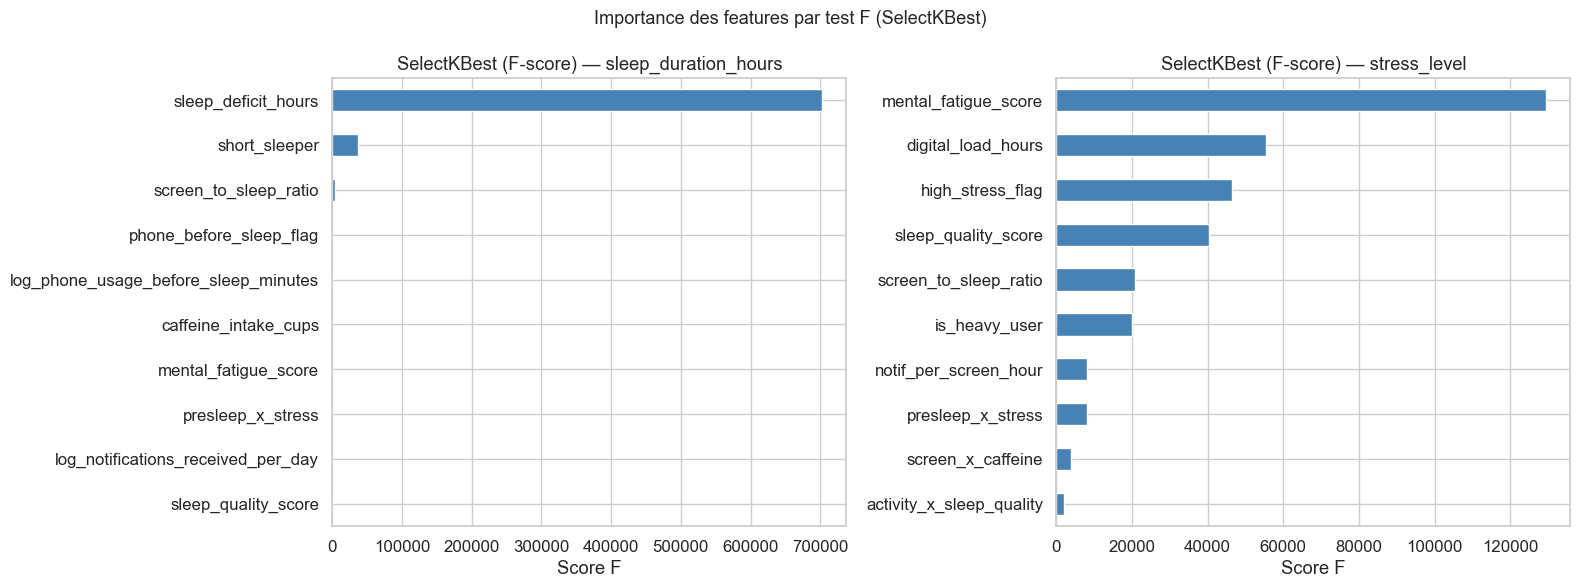

In [6]:
# Visualisation des F-scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (target, scores) in zip(axes, results.items()):
    top = scores.head(K)
    top.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'SelectKBest (F-score) — {target}')
    ax.set_xlabel('Score F')
plt.suptitle('Importance des features par test F (SelectKBest)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. SelectKBest — Information mutuelle

L'**information mutuelle** mesure toute dépendance (pas seulement linéaire). Elle est plus adaptée aux relations complexes.

In [7]:
mi_results = {}
for target_name, y in [('sleep_duration_hours', y_sleep), ('stress_level', y_stress)]:
    selector_mi = SelectKBest(score_func=mutual_info_regression, k=K)
    selector_mi.fit(X_v2, y)
    mi_scores = pd.Series(selector_mi.scores_, index=feature_cols_v2).sort_values(ascending=False)
    mi_results[target_name] = mi_scores
    print(f'\nTop {K} features (Info. Mutuelle) pour {target_name} :')
    print(mi_scores.head(K).round(4).to_string())


Top 10 features (Info. Mutuelle) pour sleep_duration_hours :
sleep_deficit_hours              5.2276
short_sleeper                    0.6739
screen_to_sleep_ratio            0.2495
activity_x_sleep_quality         0.0100
screen_x_caffeine                0.0091
age                              0.0068
is_heavy_user                    0.0037
log_physical_activity_minutes    0.0026
presleep_x_stress                0.0022
digital_load_hours               0.0021

Top 10 features (Info. Mutuelle) pour stress_level :
mental_fatigue_score        0.9944
digital_load_hours          0.7947
sleep_quality_score         0.7230
high_stress_flag            0.6993
presleep_x_stress           0.6720
screen_to_sleep_ratio       0.5403
is_heavy_user               0.4175
screen_x_caffeine           0.2972
notif_per_screen_hour       0.2851
activity_x_sleep_quality    0.1117


## 6. Importance par Random Forest

Un Random Forest entraîné sur les données donne une mesure d'importance basée sur la **réduction d'impureté** à chaque split.


Top 10 features (RF importance) pour sleep_duration_hours :
sleep_deficit_hours                     0.9989
screen_to_sleep_ratio                   0.0006
digital_load_hours                      0.0003
presleep_x_stress                       0.0001
log_phone_usage_before_sleep_minutes    0.0001
screen_x_caffeine                       0.0000
notif_per_screen_hour                   0.0000
sleep_quality_score                     0.0000
mental_fatigue_score                    0.0000
log_physical_activity_minutes           0.0000

Top 10 features (RF importance) pour stress_level :
high_stress_flag                        0.7882
mental_fatigue_score                    0.1610
digital_load_hours                      0.0226
sleep_quality_score                     0.0148
presleep_x_stress                       0.0060
log_phone_usage_before_sleep_minutes    0.0035
screen_to_sleep_ratio                   0.0015
notif_per_screen_hour                   0.0005
screen_x_caffeine                       

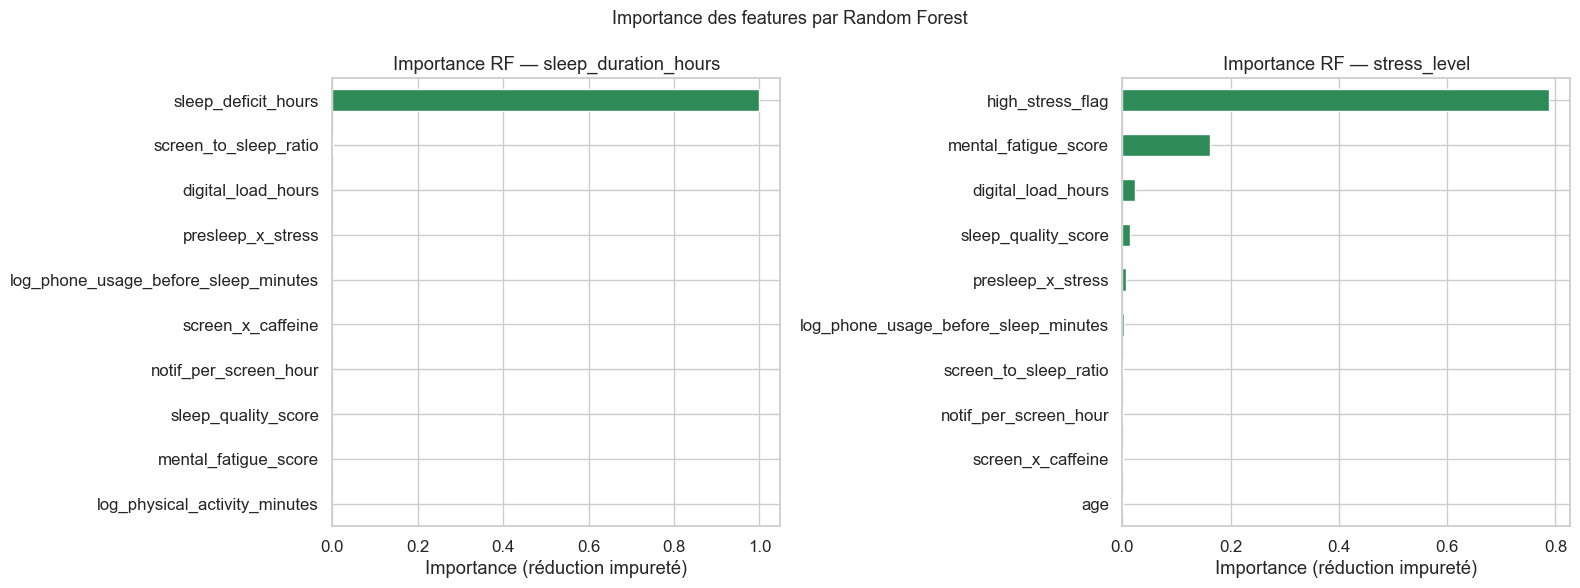

In [8]:
rf_importances = {}
for target_name, y in [('sleep_duration_hours', y_sleep), ('stress_level', y_stress)]:
    rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(X_v2, y)
    importances = pd.Series(rf.feature_importances_, index=feature_cols_v2).sort_values(ascending=False)
    rf_importances[target_name] = importances
    print(f'\nTop {K} features (RF importance) pour {target_name} :')
    print(importances.head(K).round(4).to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (target, imp) in zip(axes, rf_importances.items()):
    top = imp.head(K).sort_values()
    top.plot(kind='barh', ax=ax, color='seagreen')
    ax.set_title(f'Importance RF — {target}')
    ax.set_xlabel('Importance (réduction impureté)')
plt.suptitle('Importance des features par Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

## 7. RFE — Recursive Feature Elimination

La **RFE** entraîne un modèle, retire la feature la moins importante, recommence jusqu'à obtenir le nombre souhaité de features.

In [9]:
rfe_results = {}
for target_name, y in [('sleep_duration_hours', y_sleep), ('stress_level', y_stress)]:
    estimator = LinearRegression()
    rfe = RFE(estimator=estimator, n_features_to_select=K, step=1)
    rfe.fit(X_v2, y)
    selected = [f for f, s in zip(feature_cols_v2, rfe.support_) if s]
    rfe_results[target_name] = selected
    print(f'\nFeatures sélectionnées par RFE pour {target_name} :')
    for i, f in enumerate(selected, 1):
        print(f'  {i:>2}. {f}')


Features sélectionnées par RFE pour sleep_duration_hours :
   1. caffeine_intake_cups
   2. screen_to_sleep_ratio
   3. notif_per_screen_hour
   4. digital_load_hours
   5. sleep_deficit_hours
   6. is_heavy_user
   7. phone_before_sleep_flag
   8. short_sleeper
   9. log_phone_usage_before_sleep_minutes
  10. log_notifications_received_per_day

Features sélectionnées par RFE pour stress_level :
   1. sleep_quality_score
   2. mental_fatigue_score
   3. screen_to_sleep_ratio
   4. notif_per_screen_hour
   5. digital_load_hours
   6. sleep_deficit_hours
   7. high_stress_flag
   8. log_phone_usage_before_sleep_minutes
   9. log_notifications_received_per_day
  10. presleep_x_stress


## 8. Synthèse : tableau de vote

On regroupe les résultats de toutes les méthodes et on garde les features sélectionnées par **au moins 2 méthodes sur 3**.

In [10]:
def top_k_set(series, k):
    return set(series.head(k).index)

for target_name, y in [('sleep_duration_hours', y_sleep), ('stress_level', y_stress)]:
    print(f'\n=== {target_name} ===')
    top_f   = top_k_set(results[target_name], K)
    top_mi  = top_k_set(mi_results[target_name], K)
    top_rf  = top_k_set(rf_importances[target_name], K)
    top_rfe = set(rfe_results[target_name])

    all_feats = top_f | top_mi | top_rf | top_rfe
    vote_df = pd.DataFrame(index=sorted(all_feats))
    vote_df['F-test']   = vote_df.index.isin(top_f).astype(int)
    vote_df['Mut.Info'] = vote_df.index.isin(top_mi).astype(int)
    vote_df['RF']       = vote_df.index.isin(top_rf).astype(int)
    vote_df['RFE']      = vote_df.index.isin(top_rfe).astype(int)
    vote_df['Total']    = vote_df.sum(axis=1)
    vote_df = vote_df.sort_values('Total', ascending=False)
    print(vote_df.to_string())
    
    selected_final = vote_df[vote_df['Total'] >= 2].index.tolist()
    print(f'\n→ Features retenues (≥ 2 votes) : {selected_final}')


=== sleep_duration_hours ===
                                      F-test  Mut.Info  RF  RFE  Total
sleep_deficit_hours                        1         1   1    1      4
screen_to_sleep_ratio                      1         1   1    1      4
presleep_x_stress                          1         1   1    0      3
digital_load_hours                         0         1   1    1      3
log_phone_usage_before_sleep_minutes       1         0   1    1      3
short_sleeper                              1         1   0    1      3
notif_per_screen_hour                      0         0   1    1      2
is_heavy_user                              0         1   0    1      2
caffeine_intake_cups                       1         0   0    1      2
screen_x_caffeine                          0         1   1    0      2
mental_fatigue_score                       1         0   1    0      2
log_notifications_received_per_day         1         0   0    1      2
log_physical_activity_minutes              0   

In [11]:
# Export de la liste finale de features
selected_sleep  = vote_df[vote_df['Total'] >= 2].index.tolist()  # Dernière itération = stress
# On refait pour sleep
for target_name, y in [('sleep_duration_hours', y_sleep)]:
    top_f   = top_k_set(results[target_name], K)
    top_mi  = top_k_set(mi_results[target_name], K)
    top_rf  = top_k_set(rf_importances[target_name], K)
    top_rfe = set(rfe_results[target_name])
    all_feats = top_f | top_mi | top_rf | top_rfe
    vote_df_sleep = pd.DataFrame(index=sorted(all_feats))
    for col, s in [('F-test', top_f), ('Mut.Info', top_mi), ('RF', top_rf), ('RFE', top_rfe)]:
        vote_df_sleep[col] = vote_df_sleep.index.isin(s).astype(int)
    vote_df_sleep['Total'] = vote_df_sleep.sum(axis=1)
    selected_sleep = vote_df_sleep[vote_df_sleep['Total'] >= 2].index.tolist()

print('Features finales pour sleep_duration_hours :')
print(selected_sleep)

import json
with open('selected_features.json', 'w') as f:
    json.dump({'sleep': selected_sleep, 'stress': selected_final}, f, indent=2)
print('\n✅ Exporté : selected_features.json')

Features finales pour sleep_duration_hours :
['caffeine_intake_cups', 'digital_load_hours', 'is_heavy_user', 'log_notifications_received_per_day', 'log_phone_usage_before_sleep_minutes', 'log_physical_activity_minutes', 'mental_fatigue_score', 'notif_per_screen_hour', 'phone_before_sleep_flag', 'presleep_x_stress', 'screen_to_sleep_ratio', 'screen_x_caffeine', 'short_sleeper', 'sleep_deficit_hours', 'sleep_quality_score']

✅ Exporté : selected_features.json
